<a href="https://colab.research.google.com/github/luuizfr/PE_Sistema_Automotivo/blob/Modelo_Classificador/PE_Sistema_Automotivo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Multi view learning

Cotraining - semi supervisionado

Tom M Mitchell - Machine learning

# Importação de Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
sales_df = pd.read_csv('sales_20260218.csv')

# Analise Exploratória

In [3]:
sales_df.head()

,sale_id,customer_id,sale_date,sale_value,used_in_exchange,product_description,customer_type
0,81703409-4fe5-429d-bb9f-d1c40aae1056,d5e8fc02-f041-4695-9689-6a31333febe3,2026-02-05 00:03:19.207,199000.0,False,KICKS 1.0T PLATINUM AT,PERSON
1,41d84cf6-4715-47af-9940-5824f4f8b844,c749de96-bd66-4602-b1f2-924b554ad77e,2026-02-04 23:53:44.415,115900.0,False,KICKS PLAY 1.6 SENSE CVT,PERSON
2,4b98d279-150d-4bf0-b301-e3d519910aa3,0706a533-ac37-46c0-b447-22c0e8ec828d,2026-02-04 22:04:45.517,19150.0,False,NS160,PERSON
3,6e593111-eb84-40e5-8c0e-9a7b295854cc,9b1cbbed-a816-4749-ac65-e46e8798a5e7,2026-02-04 21:01:02.683,26990.0,False,DOMINAR NS400Z,PERSON
4,a0930c20-de95-419b-a0f4-8b5cfa5f1d10,055885e9-918c-4dbf-9e8b-3ee9790a8493,2026-02-04 21:00:45.905,159990.0,False,OMODA 5 LUXURY HEV CL,PERSON


In [4]:
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75937 entries, 0 to 75936
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   sale_id              75937 non-null  object 
 1   customer_id          75934 non-null  object 
 2   sale_date            75937 non-null  object 
 3   sale_value           75871 non-null  float64
 4   used_in_exchange     18592 non-null  object 
 5   product_description  75937 non-null  object 
 6   customer_type        75934 non-null  object 
dtypes: float64(1), object(6)
memory usage: 4.1+ MB


In [5]:
sales_df.describe()

,sale_value
count,7.587100e+04
mean,1.365879e+05
std,3.197766e+05
min,0.000000e+00
25%,5.940307e+04
50%,1.069000e+05
75%,1.820000e+05
max,6.747455e+07


# Limpeza e Tratamento de Dados

## Tratamento de Valores Nulos e Ausentes

In [6]:
sales_df['used_in_exchange'] = sales_df['used_in_exchange'].fillna(False)

/tmp/ipykernel_3220/1246533086.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sales_df['used_in_exchange'] = sales_df['used_in_exchange'].fillna(False)


In [7]:
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75937 entries, 0 to 75936
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   sale_id              75937 non-null  object 
 1   customer_id          75934 non-null  object 
 2   sale_date            75937 non-null  object 
 3   sale_value           75871 non-null  float64
 4   used_in_exchange     75937 non-null  bool   
 5   product_description  75937 non-null  object 
 6   customer_type        75934 non-null  object 
dtypes: bool(1), float64(1), object(5)
memory usage: 3.5+ MB


In [8]:
sales_df['customer_id'] = sales_df['customer_id'].dropna()

In [9]:
sales_df.dropna(subset=['customer_id'], inplace=True)

In [10]:
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 75934 entries, 0 to 75936
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   sale_id              75934 non-null  object 
 1   customer_id          75934 non-null  object 
 2   sale_date            75934 non-null  object 
 3   sale_value           75868 non-null  float64
 4   used_in_exchange     75934 non-null  bool   
 5   product_description  75934 non-null  object 
 6   customer_type        75934 non-null  object 
dtypes: bool(1), float64(1), object(5)
memory usage: 4.1+ MB


## Imputação de Valores de Venda Zerados ou Faltantes

In [11]:
sales_without_value = sales_df[(sales_df['sale_value'] == 0) | (sales_df['sale_value'].isnull())]

In [12]:
sales_without_value.head()

,sale_id,customer_id,sale_date,sale_value,used_in_exchange,product_description,customer_type
1671,8603b97e-9538-4f81-a5eb-6a6e31105c92,65736069-a7ff-42ec-88ef-7e98c468b0df,2025-07-19 00:00:00.000,NaN,False,KICKS 1 6 ACTIVE CVT,PERSON
1684,ce967ee9-d358-4b0d-8bab-89faf9ad0ffd,09fc73ee-a581-4910-ba6f-dd170b9f8e0f,2025-07-18 00:00:00.000,NaN,False,KICKS 1 6 ACTIVE CVT,PERSON
1685,1bd2849a-285b-4c73-a852-7840ad69b821,7712837f-91f8-4f00-9fd0-1702877e23c1,2025-07-18 00:00:00.000,NaN,False,KICKS 1 6 ACTIVE CVT,PERSON
1987,eac3682b-4ec3-408f-aa36-9d1465eb204b,acf16c78-54aa-4a80-8f9c-46eb6760b214,2025-06-28 00:00:00.000,NaN,False,KICKS 1 6 ACTIVE CVT,PERSON
2063,9b0ea0b7-7b50-4de1-ae74-c61fa46b5d64,fbb18557-c236-4b8a-ac16-a3c56c25474d,2025-06-24 00:00:00.000,NaN,False,VERSA 1 6 ADVANCE CVT,PERSON


In [13]:
venda_kicks = sales_df[(sales_df['product_description'] == 'KICKS 1 6 ACTIVE CVT') & (sales_df['sale_value'].notnull())]
venda_kicks.head()

,sale_id,customer_id,sale_date,sale_value,used_in_exchange,product_description,customer_type
5237,edda7fbb-63f8-4aef-8a8c-cc5444548b88,b1b7403a-74a7-43e9-b5b3-ed5b52e901ca,2024-12-06 15:20:20.000,122900.0,False,KICKS 1 6 ACTIVE CVT,PERSON
5499,8e1954a9-857c-4395-b63d-c35e92953134,780d4210-39a6-433c-a212-ad493f9d9383,2024-11-26 15:02:45.000,119990.0,False,KICKS 1 6 ACTIVE CVT,PERSON
8510,d0496c40-88c6-4bb7-872f-9aa0af0b1817,a959acbc-5372-4b48-8e74-c35482a133b9,2024-05-13 15:05:43.000,110600.0,False,KICKS 1 6 ACTIVE CVT,PERSON
8874,eae7136c-64cd-4be4-8ae7-cd8467c4131f,f09ff604-5d58-4ea7-861c-9134fda1a34e,2024-04-17 20:51:23.000,114000.0,False,KICKS 1 6 ACTIVE CVT,COMPANY
8969,6dece800-64ec-4d21-90df-020878367628,4a6de531-17e1-4c5c-b57a-792c863b9f8a,2024-04-10 21:38:42.000,103900.0,False,KICKS 1 6 ACTIVE CVT,PERSON


In [14]:
zero_sale_values_count = sales_df[sales_df['sale_value'] == 0].shape[0]
print(f"Number of 'sale_value' entries equal to 0 after filling: {zero_sale_values_count}")

Number of 'sale_value' entries equal to 0 after filling: 1


In [15]:
sales_df[sales_df['sale_value'] == 0]

,sale_id,customer_id,sale_date,sale_value,used_in_exchange,product_description,customer_type
5282,b00ed6b4-191f-4201-bbfc-183316fd0692,9185c987-e9ff-4a7d-ac48-f1cb52ec5e23,2024-12-04 03:00:00.000,0.0,False,HILUX CD DSL 4X4 SRX AT 24/25,PERSON


In [16]:
venda_kicks

,sale_id,customer_id,sale_date,sale_value,used_in_exchange,product_description,customer_type
5237,edda7fbb-63f8-4aef-8a8c-cc5444548b88,b1b7403a-74a7-43e9-b5b3-ed5b52e901ca,2024-12-06 15:20:20.000,122900.00,False,KICKS 1 6 ACTIVE CVT,PERSON
5499,8e1954a9-857c-4395-b63d-c35e92953134,780d4210-39a6-433c-a212-ad493f9d9383,2024-11-26 15:02:45.000,119990.00,False,KICKS 1 6 ACTIVE CVT,PERSON
8510,d0496c40-88c6-4bb7-872f-9aa0af0b1817,a959acbc-5372-4b48-8e74-c35482a133b9,2024-05-13 15:05:43.000,110600.00,False,KICKS 1 6 ACTIVE CVT,PERSON
8874,eae7136c-64cd-4be4-8ae7-cd8467c4131f,f09ff604-5d58-4ea7-861c-9134fda1a34e,2024-04-17 20:51:23.000,114000.00,False,KICKS 1 6 ACTIVE CVT,COMPANY
8969,6dece800-64ec-4d21-90df-020878367628,4a6de531-17e1-4c5c-b57a-792c863b9f8a,2024-04-10 21:38:42.000,103900.00,False,KICKS 1 6 ACTIVE CVT,PERSON
8991,33e9f4d1-32ae-4996-8649-9f7946756f0d,f4af65af-5250-436c-966d-d68b71a28c42,2024-04-09 18:56:07.000,102520.00,False,KICKS 1 6 ACTIVE CVT,PERSON
9227,3a0e1315-ceec-4bbd-9fa5-33f58a2043d9,81484c58-7232-400b-8eb6-7be121dc5051,2024-03-26 19:12:15.000,103000.00,False,KICKS 1 6 ACTIVE CVT,PERSON
9228,4c3272e8-7ada-40c0-891b-18dc4ed48ae9,0d029032-8434-40cb-b9b9-46558f58401c,2024-03-26 19:11:51.000,103990.00,False,KICKS 1 6 ACTIVE CVT,PERSON
9300,eb037c48-fbd6-4453-8a1a-ee28c9a223f4,1ca91474-2057-4b88-945d-61a4f3730778,2024-03-21 18:58:42.000,112900.00,False,KICKS 1 6 ACTIVE CVT,PERSON
9534,72498016-eea9-473d-a4c1-1d4713fb8756,0111aed2-4fc1-4219-9a37-c69b9da769f8,2024-03-04 13:55:35.000,105150.00,True,KICKS 1 6 ACTIVE CVT,PERSON


In [17]:
def fill_missing_sale_value(df, value_col='sale_value', group_col='product_description'):

    temp_df = df.copy()

    temp_df.loc[temp_df[value_col] == 0, value_col] = np.nan

    product_mean_sales = temp_df.groupby(group_col)[value_col].transform('mean')

    temp_df[value_col] = temp_df[value_col].fillna(product_mean_sales)

    overall_mean_sales = temp_df[value_col].mean()
    temp_df[value_col] = temp_df[value_col].fillna(overall_mean_sales)

    df[value_col] = temp_df[value_col]

    return df

sales_df = fill_missing_sale_value(sales_df, 'sale_value', 'product_description')

sales_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 75934 entries, 0 to 75936
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   sale_id              75934 non-null  object 
 1   customer_id          75934 non-null  object 
 2   sale_date            75934 non-null  object 
 3   sale_value           75934 non-null  float64
 4   used_in_exchange     75934 non-null  bool   
 5   product_description  75934 non-null  object 
 6   customer_type        75934 non-null  object 
dtypes: bool(1), float64(1), object(5)
memory usage: 4.1+ MB


# Analise Temporal e Visualização

In [18]:
sales_df['sale_date'] = pd.to_datetime(sales_df['sale_date'], format='mixed')

sales_2024 = sales_df[sales_df['sale_date'].dt.year == 2024].copy()

sales_2024_monthly = sales_2024.groupby(sales_2024['sale_date'].dt.to_period('M'))['sale_value'].sum().reset_index()
sales_2024_monthly['sale_date'] = sales_2024_monthly['sale_date'].dt.strftime('%Y-%m')
sales_2024_monthly.rename(columns={'sale_date': 'month'}, inplace=True)

display(sales_2024_monthly)

,month,sale_value
0,2024-01,8.511816e+07
1,2024-02,7.383283e+07
2,2024-03,9.352893e+07
3,2024-04,9.179999e+07
4,2024-05,7.111821e+07
5,2024-06,1.060966e+08
6,2024-07,9.338831e+07
7,2024-08,9.859446e+07
8,2024-09,8.482961e+07
9,2024-10,9.596485e+07


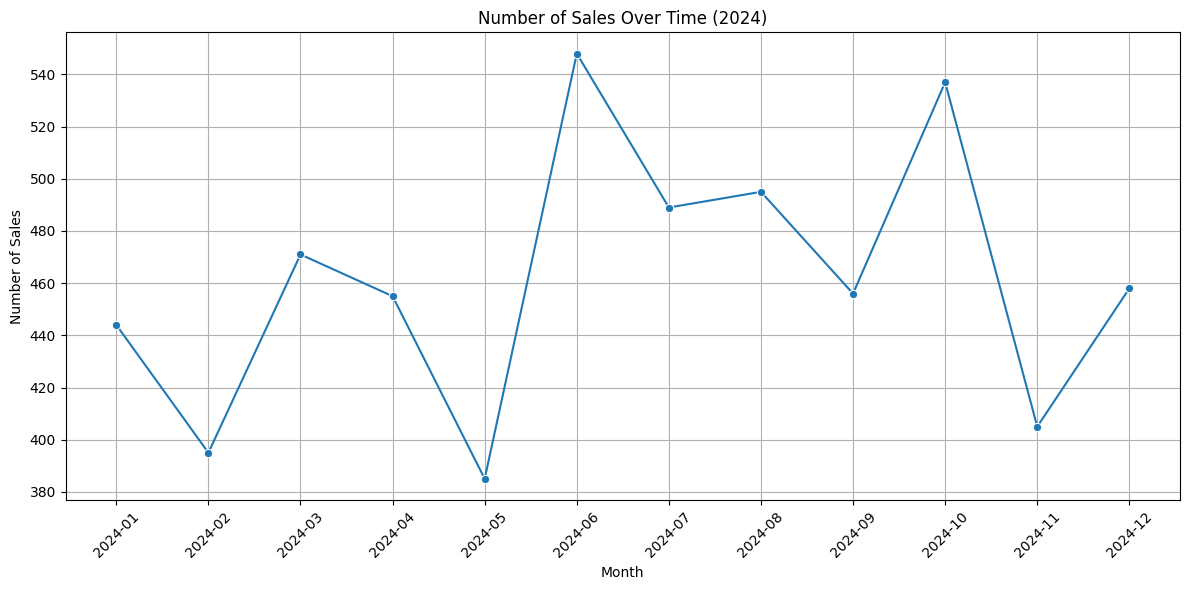

In [19]:
sales_2024_monthly_count = sales_2024.groupby(sales_2024['sale_date'].dt.to_period('M'))['sale_id'].count().reset_index()
sales_2024_monthly_count['sale_date'] = sales_2024_monthly_count['sale_date'].dt.strftime('%Y-%m')
sales_2024_monthly_count.rename(columns={'sale_id': 'sale_count', 'sale_date': 'month'}, inplace=True)

plt.figure(figsize=(12, 6))
sns.lineplot(data=sales_2024_monthly_count, x='month', y='sale_count', marker='o')
plt.title('Number of Sales Over Time (2024)')
plt.xlabel('Month')
plt.ylabel('Number of Sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

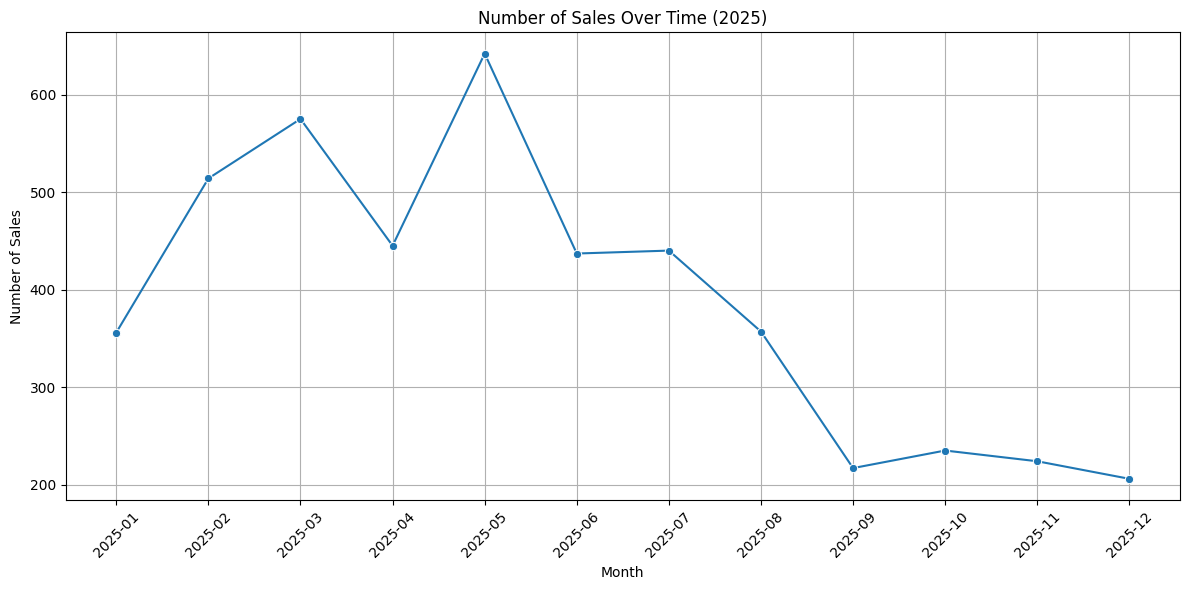

In [20]:
sales_2025 = sales_df[sales_df['sale_date'].dt.year == 2025].copy()

sales_2025_monthly_count = sales_2025.groupby(sales_2025['sale_date'].dt.to_period('M'))['sale_id'].count().reset_index()
sales_2025_monthly_count['sale_date'] = sales_2025_monthly_count['sale_date'].dt.strftime('%Y-%m')
sales_2025_monthly_count.rename(columns={'sale_id': 'sale_count', 'sale_date': 'month'}, inplace=True)

plt.figure(figsize=(12, 6))
sns.lineplot(data=sales_2025_monthly_count, x='month', y='sale_count', marker='o')
plt.title('Number of Sales Over Time (2025)')
plt.xlabel('Month')
plt.ylabel('Number of Sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

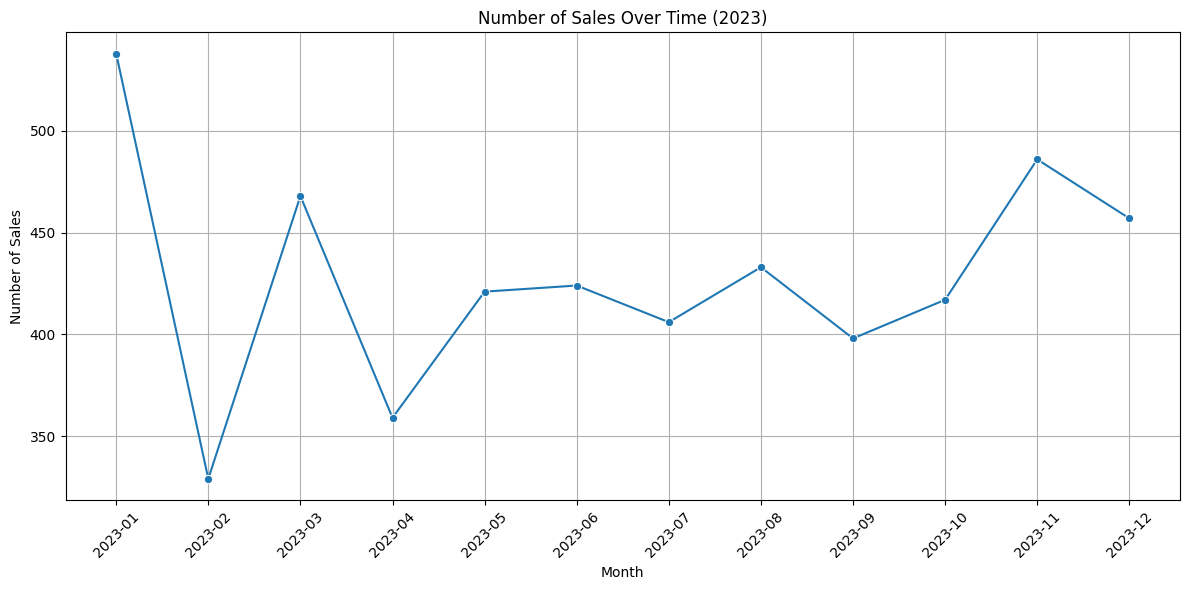

In [21]:
sales_2023 = sales_df[sales_df['sale_date'].dt.year == 2023].copy()

sales_2023_monthly_count = sales_2023.groupby(sales_2023['sale_date'].dt.to_period('M'))['sale_id'].count().reset_index()
sales_2023_monthly_count['sale_date'] = sales_2023_monthly_count['sale_date'].dt.strftime('%Y-%m')
sales_2023_monthly_count.rename(columns={'sale_id': 'sale_count', 'sale_date': 'month'}, inplace=True)

plt.figure(figsize=(12, 6))
sns.lineplot(data=sales_2023_monthly_count, x='month', y='sale_count', marker='o')
plt.title('Number of Sales Over Time (2023)')
plt.xlabel('Month')
plt.ylabel('Number of Sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

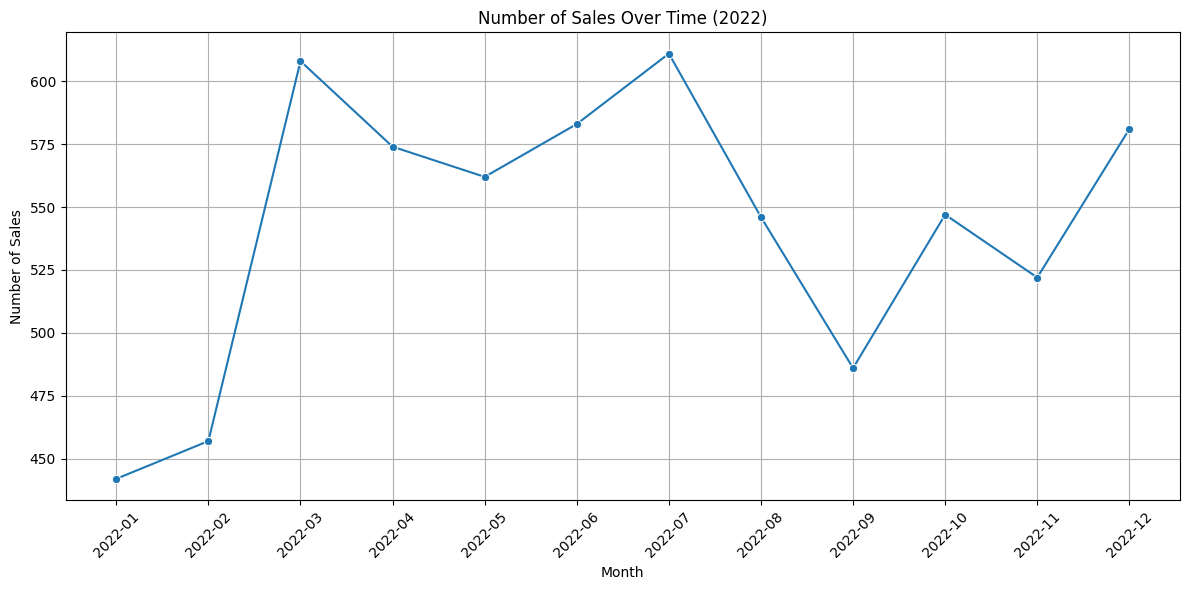

In [22]:
sales_2022 = sales_df[sales_df['sale_date'].dt.year == 2022].copy()

sales_2022_monthly_count = sales_2022.groupby(sales_2022['sale_date'].dt.to_period('M'))['sale_id'].count().reset_index()
sales_2022_monthly_count['sale_date'] = sales_2022_monthly_count['sale_date'].dt.strftime('%Y-%m')
sales_2022_monthly_count.rename(columns={'sale_id': 'sale_count', 'sale_date': 'month'}, inplace=True)

plt.figure(figsize=(12, 6))
sns.lineplot(data=sales_2022_monthly_count, x='month', y='sale_count', marker='o')
plt.title('Number of Sales Over Time (2022)')
plt.xlabel('Month')
plt.ylabel('Number of Sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [23]:
sales_2022_monthly_count['year'] = 2022
sales_2023_monthly_count['year'] = 2023
sales_2024_monthly_count['year'] = 2024
sales_2025_monthly_count['year'] = 2025

combined_sales_monthly = pd.concat([
    sales_2022_monthly_count,
    sales_2023_monthly_count,
    sales_2024_monthly_count,
    sales_2025_monthly_count
])

# Display the head of the combined DataFrame to verify
print(combined_sales_monthly.head())
# Display the tail to ensure all years are included
print(combined_sales_monthly.tail())

     month  sale_count  year
0  2022-01         442  2022
1  2022-02         457  2022
2  2022-03         608  2022
3  2022-04         574  2022
4  2022-05         562  2022
      month  sale_count  year
7   2025-08         357  2025
8   2025-09         217  2025
9   2025-10         235  2025
10  2025-11         224  2025
11  2025-12         206  2025


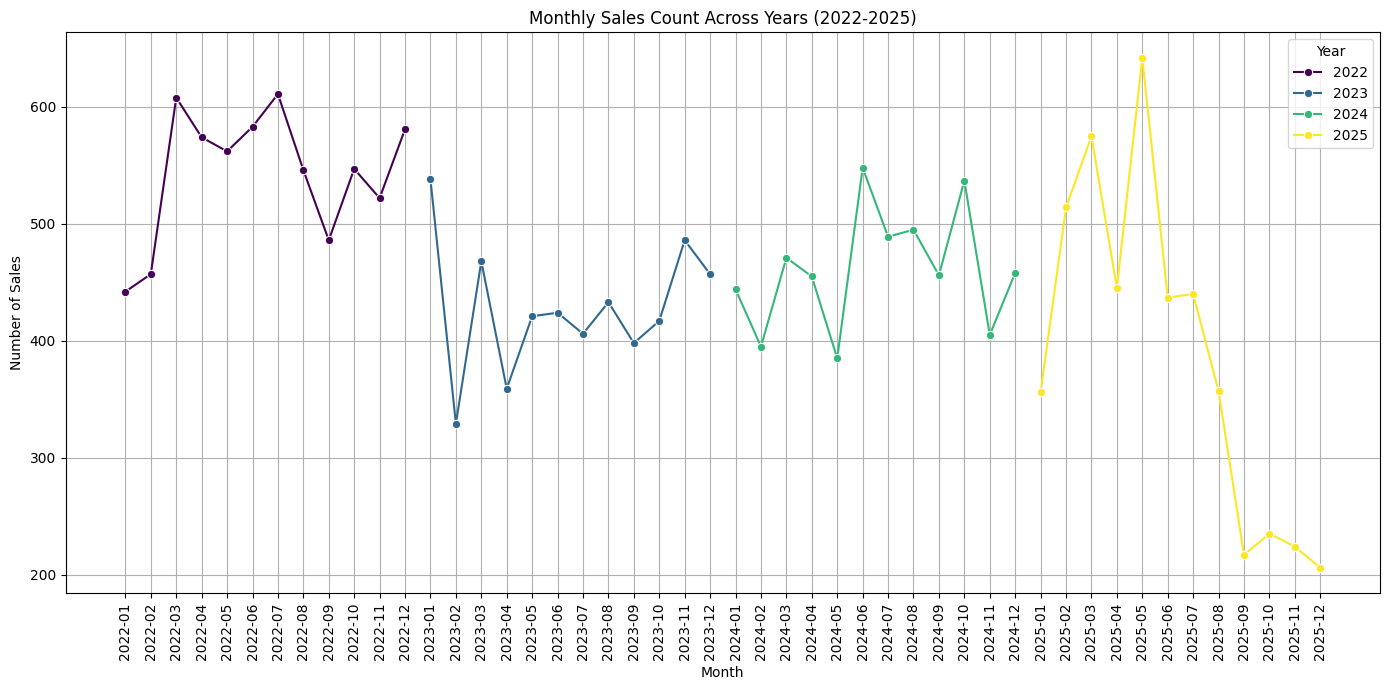

In [24]:
plt.figure(figsize=(14, 7))
sns.lineplot(data=combined_sales_monthly, x='month', y='sale_count', hue='year', marker='o', palette='viridis')
plt.title('Monthly Sales Count Across Years (2022-2025)')
plt.xlabel('Month')
plt.ylabel('Number of Sales')
plt.xticks(rotation=90)
plt.grid(True)
plt.legend(title='Year')
plt.tight_layout()
plt.show()

In [25]:
sales_df['purchase_month'] = sales_df['sale_date'].dt.strftime('%Y-%m')

sales_df.head()

,sale_id,customer_id,sale_date,sale_value,used_in_exchange,product_description,customer_type,purchase_month
0,81703409-4fe5-429d-bb9f-d1c40aae1056,d5e8fc02-f041-4695-9689-6a31333febe3,2026-02-05 00:03:19.207,199000.0,False,KICKS 1.0T PLATINUM AT,PERSON,2026-02
1,41d84cf6-4715-47af-9940-5824f4f8b844,c749de96-bd66-4602-b1f2-924b554ad77e,2026-02-04 23:53:44.415,115900.0,False,KICKS PLAY 1.6 SENSE CVT,PERSON,2026-02
2,4b98d279-150d-4bf0-b301-e3d519910aa3,0706a533-ac37-46c0-b447-22c0e8ec828d,2026-02-04 22:04:45.517,19150.0,False,NS160,PERSON,2026-02
3,6e593111-eb84-40e5-8c0e-9a7b295854cc,9b1cbbed-a816-4749-ac65-e46e8798a5e7,2026-02-04 21:01:02.683,26990.0,False,DOMINAR NS400Z,PERSON,2026-02
4,a0930c20-de95-419b-a0f4-8b5cfa5f1d10,055885e9-918c-4dbf-9e8b-3ee9790a8493,2026-02-04 21:00:45.905,159990.0,False,OMODA 5 LUXURY HEV CL,PERSON,2026-02


# Clusterização Manual de Lojistas/Pessoa Física

In [26]:
frequencia_compras = sales_df.groupby('customer_id')['purchase_month'].nunique().reset_index()
frequencia_compras.rename(columns={'purchase_month': 'frequencia_compras'}, inplace=True)
frequencia_compras.head()

,customer_id,frequencia_compras
0,0005a54b-e0fe-492c-af30-d0424f946dd4,1
1,0005ce19-40ed-479d-802f-8c4abb95627f,1
2,00066896-69a1-4cbb-875c-819c1aaca5dc,1
3,0006dd48-1c74-4c6c-91cf-d6179c6f35b8,1
4,0009d0b8-d31e-40a8-94d8-4d4758433523,1


In [27]:
monthly_purchase_dates = sales_df.groupby(['customer_id', 'purchase_month'])['sale_date'].min().reset_index()
monthly_purchase_dates = monthly_purchase_dates.sort_values(by=['customer_id', 'sale_date'])

monthly_purchase_dates.head()

,customer_id,purchase_month,sale_date
0,0005a54b-e0fe-492c-af30-d0424f946dd4,2015-03,2015-03-25 00:00:00
1,0005ce19-40ed-479d-802f-8c4abb95627f,2022-07,2022-07-11 13:47:15
2,00066896-69a1-4cbb-875c-819c1aaca5dc,2022-04,2022-04-20 00:00:00
3,0006dd48-1c74-4c6c-91cf-d6179c6f35b8,2012-11,2012-11-26 00:00:00
4,0009d0b8-d31e-40a8-94d8-4d4758433523,2014-10,2014-10-28 00:00:00


In [28]:
monthly_purchase_dates['date_diff'] = monthly_purchase_dates.groupby('customer_id')['sale_date'].diff().dt.days
dias_medios_entre_compras = monthly_purchase_dates.groupby('customer_id')['date_diff'].mean().reset_index()
dias_medios_entre_compras.rename(columns={'date_diff': 'dias_medios_entre_compras'}, inplace=True)

dias_medios_entre_compras['dias_medios_entre_compras'] = dias_medios_entre_compras['dias_medios_entre_compras'].fillna(0)

dias_medios_entre_compras.head()

,customer_id,dias_medios_entre_compras
0,0005a54b-e0fe-492c-af30-d0424f946dd4,0.0
1,0005ce19-40ed-479d-802f-8c4abb95627f,0.0
2,00066896-69a1-4cbb-875c-819c1aaca5dc,0.0
3,0006dd48-1c74-4c6c-91cf-d6179c6f35b8,0.0
4,0009d0b8-d31e-40a8-94d8-4d4758433523,0.0


In [29]:
taxa_de_troca = sales_df.groupby('customer_id').agg(
    exchanges=('used_in_exchange', lambda x: x.sum().astype(int)),
    total_sales=('sale_id', 'count')
).reset_index()

taxa_de_troca['taxa_de_troca'] = taxa_de_troca['exchanges'] / taxa_de_troca['total_sales']

taxa_de_troca['taxa_de_troca'] = taxa_de_troca['taxa_de_troca'].fillna(0)

taxa_de_troca = taxa_de_troca[['customer_id', 'taxa_de_troca']]

taxa_de_troca.head()

,customer_id,taxa_de_troca
0,0005a54b-e0fe-492c-af30-d0424f946dd4,0.0
1,0005ce19-40ed-479d-802f-8c4abb95627f,0.0
2,00066896-69a1-4cbb-875c-819c1aaca5dc,0.0
3,0006dd48-1c74-4c6c-91cf-d6179c6f35b8,0.0
4,0009d0b8-d31e-40a8-94d8-4d4758433523,0.0


In [30]:
product_counts = sales_df.groupby(['customer_id', 'product_description'])['sale_id'].count().reset_index()
product_counts.rename(columns={'sale_id': 'sale_count'}, inplace=True)

repeat_purchases = product_counts[product_counts['sale_count'] > 1]

compras_mesmo_produto = repeat_purchases.groupby('customer_id')['sale_count'].apply(lambda x: (x - 1).sum()).reset_index()
compras_mesmo_produto.rename(columns={'sale_count': 'compras_mesmo_produto'}, inplace=True)

all_customers = sales_df[['customer_id']].drop_duplicates()
compras_mesmo_produto = pd.merge(
    all_customers,
    compras_mesmo_produto,
    on='customer_id',
    how='left'
).fillna(0)

compras_mesmo_produto['compras_mesmo_produto'] = compras_mesmo_produto['compras_mesmo_produto'].astype(int)

compras_mesmo_produto.head()

,customer_id,compras_mesmo_produto
0,d5e8fc02-f041-4695-9689-6a31333febe3,0
1,c749de96-bd66-4602-b1f2-924b554ad77e,0
2,0706a533-ac37-46c0-b447-22c0e8ec828d,0
3,9b1cbbed-a816-4749-ac65-e46e8798a5e7,0
4,055885e9-918c-4dbf-9e8b-3ee9790a8493,0


In [31]:
ticket_medio = sales_df.groupby('customer_id')['sale_value'].mean().reset_index()
ticket_medio.rename(columns={'sale_value': 'ticket_medio'}, inplace=True)

ticket_medio.head()

,customer_id,ticket_medio
0,0005a54b-e0fe-492c-af30-d0424f946dd4,50740.00
1,0005ce19-40ed-479d-802f-8c4abb95627f,114000.00
2,00066896-69a1-4cbb-875c-819c1aaca5dc,150209.72
3,0006dd48-1c74-4c6c-91cf-d6179c6f35b8,134000.00
4,0009d0b8-d31e-40a8-94d8-4d4758433523,90000.00


In [32]:
customer_data = pd.merge(frequencia_compras, dias_medios_entre_compras, on='customer_id', how='left')
customer_data.head()

,customer_id,frequencia_compras,dias_medios_entre_compras
0,0005a54b-e0fe-492c-af30-d0424f946dd4,1,0.0
1,0005ce19-40ed-479d-802f-8c4abb95627f,1,0.0
2,00066896-69a1-4cbb-875c-819c1aaca5dc,1,0.0
3,0006dd48-1c74-4c6c-91cf-d6179c6f35b8,1,0.0
4,0009d0b8-d31e-40a8-94d8-4d4758433523,1,0.0


In [33]:
customer_data = pd.merge(customer_data, taxa_de_troca, on='customer_id', how='left')
customer_data.head()

,customer_id,frequencia_compras,dias_medios_entre_compras,taxa_de_troca
0,0005a54b-e0fe-492c-af30-d0424f946dd4,1,0.0,0.0
1,0005ce19-40ed-479d-802f-8c4abb95627f,1,0.0,0.0
2,00066896-69a1-4cbb-875c-819c1aaca5dc,1,0.0,0.0
3,0006dd48-1c74-4c6c-91cf-d6179c6f35b8,1,0.0,0.0
4,0009d0b8-d31e-40a8-94d8-4d4758433523,1,0.0,0.0


In [34]:
customer_data = pd.merge(customer_data, compras_mesmo_produto, on='customer_id', how='left')
customer_data.head()

,customer_id,frequencia_compras,dias_medios_entre_compras,taxa_de_troca,compras_mesmo_produto
0,0005a54b-e0fe-492c-af30-d0424f946dd4,1,0.0,0.0,0
1,0005ce19-40ed-479d-802f-8c4abb95627f,1,0.0,0.0,0
2,00066896-69a1-4cbb-875c-819c1aaca5dc,1,0.0,0.0,0
3,0006dd48-1c74-4c6c-91cf-d6179c6f35b8,1,0.0,0.0,0
4,0009d0b8-d31e-40a8-94d8-4d4758433523,1,0.0,0.0,0


In [35]:
customer_data = pd.merge(customer_data, ticket_medio, on='customer_id', how='left')
customer_data.head()

,customer_id,frequencia_compras,dias_medios_entre_compras,taxa_de_troca,compras_mesmo_produto,ticket_medio
0,0005a54b-e0fe-492c-af30-d0424f946dd4,1,0.0,0.0,0,50740.00
1,0005ce19-40ed-479d-802f-8c4abb95627f,1,0.0,0.0,0,114000.00
2,00066896-69a1-4cbb-875c-819c1aaca5dc,1,0.0,0.0,0,150209.72
3,0006dd48-1c74-4c6c-91cf-d6179c6f35b8,1,0.0,0.0,0,134000.00
4,0009d0b8-d31e-40a8-94d8-4d4758433523,1,0.0,0.0,0,90000.00


In [36]:
customer_data.set_index('customer_id', inplace=True)
customer_data.head()

,frequencia_compras,dias_medios_entre_compras,taxa_de_troca,compras_mesmo_produto,ticket_medio
customer_id,,,,,
0005a54b-e0fe-492c-af30-d0424f946dd4,1,0.0,0.0,0,50740.00
0005ce19-40ed-479d-802f-8c4abb95627f,1,0.0,0.0,0,114000.00
00066896-69a1-4cbb-875c-819c1aaca5dc,1,0.0,0.0,0,150209.72
0006dd48-1c74-4c6c-91cf-d6179c6f35b8,1,0.0,0.0,0,134000.00
0009d0b8-d31e-40a8-94d8-4d4758433523,1,0.0,0.0,0,90000.00


In [41]:
lojistas_to_remove = (customer_data['frequencia_compras'] > 2) & (customer_data['dias_medios_entre_compras'] < 90)
customer_data = customer_data[~lojistas_to_remove]
display(customer_data.head())
customer_data.info()

,frequencia_compras,dias_medios_entre_compras,taxa_de_troca,compras_mesmo_produto,ticket_medio
customer_id,,,,,
0005a54b-e0fe-492c-af30-d0424f946dd4,1,0.0,0.0,0,50740.00
0005ce19-40ed-479d-802f-8c4abb95627f,1,0.0,0.0,0,114000.00
00066896-69a1-4cbb-875c-819c1aaca5dc,1,0.0,0.0,0,150209.72
0006dd48-1c74-4c6c-91cf-d6179c6f35b8,1,0.0,0.0,0,134000.00
0009d0b8-d31e-40a8-94d8-4d4758433523,1,0.0,0.0,0,90000.00


<class 'pandas.core.frame.DataFrame'>
Index: 31558 entries, 0005a54b-e0fe-492c-af30-d0424f946dd4 to fffde8b9-1021-4c27-9315-9247ded4a9b9
Data columns (total 5 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   frequencia_compras         31558 non-null  int64  
 1   dias_medios_entre_compras  31558 non-null  float64
 2   taxa_de_troca              31558 non-null  float64
 3   compras_mesmo_produto      31558 non-null  int64  
 4   ticket_medio               31558 non-null  float64
dtypes: float64(3), int64(2)
memory usage: 1.4+ MB


In [42]:
customers_com_menos_de_2_vendas = (customer_data['frequencia_compras'] <= 1)
customer_data = customer_data[~customers_com_menos_de_2_vendas]
display(customer_data.head())
customer_data.info()

,frequencia_compras,dias_medios_entre_compras,taxa_de_troca,compras_mesmo_produto,ticket_medio
customer_id,,,,,
000bd487-a988-46ad-aecb-db390a11d47e,5,997.5,0.2,0,182442.000000
00149129-072b-4579-9b98-f9a7858c6542,2,1528.0,0.0,0,229609.835000
0014c0ee-431a-479e-af3f-7a649995448c,2,642.0,0.0,0,159510.000000
0016e2dc-6a8f-4fcd-af1f-0d932cd05d68,2,1447.0,0.0,0,341040.000000
00184324-d3be-42b2-8037-f7fb208042ba,2,854.0,0.0,1,103493.333333


<class 'pandas.core.frame.DataFrame'>
Index: 5444 entries, 000bd487-a988-46ad-aecb-db390a11d47e to fffde8b9-1021-4c27-9315-9247ded4a9b9
Data columns (total 5 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   frequencia_compras         5444 non-null   int64  
 1   dias_medios_entre_compras  5444 non-null   float64
 2   taxa_de_troca              5444 non-null   float64
 3   compras_mesmo_produto      5444 non-null   int64  
 4   ticket_medio               5444 non-null   float64
dtypes: float64(3), int64(2)
memory usage: 255.2+ KB


In [54]:
import pandas as pd

# 1. Determine the latest sale date in the entire sales_df
latest_sale_date = sales_df['sale_date'].max()

# Define the range for the snapshots: every 4 months, going back up to 2 years
# Start from the latest sale date and go backwards
current_snapshot_iterator = latest_sale_date
two_years_ago = latest_sale_date - pd.DateOffset(years=2)

# Get customer IDs relevant for filtering sales
customer_ids_in_data = customer_data.index
relevant_sales = sales_df[sales_df['customer_id'].isin(customer_ids_in_data)].copy()

print(f"Latest Sale Date: {latest_sale_date}")
print(f"Snapshots will be generated every 4 months, going back up to: {two_years_ago.strftime('%Y-%m-%d')}")

# If 'bought_in_2_months_post_snapshot' exists, remove it before adding new snapshot columns
# This ensures clear, date-specific snapshot columns are added.
if 'bought_in_2_months_post_snapshot' in customer_data.columns:
    customer_data = customer_data.drop(columns=['bought_in_2_months_post_snapshot'])

snapshot_count = 0
while current_snapshot_iterator >= two_years_ago:
    # Set the current snapshot date
    snapshot_date = current_snapshot_iterator

    # Define the 2-month window *after* the snapshot date
    window_start_date = snapshot_date
    window_end_date = snapshot_date + pd.DateOffset(months=2)

    # Create a unique column name for this snapshot (e.g., 'bought_post_2026_02')
    column_name = f"bought_post_{snapshot_date.year}_{snapshot_date.month:02d}"

    print(f"\nProcessing snapshot for date: {snapshot_date.strftime('%Y-%m-%d')}")
    print(f"  2-month Window for checking purchases: {window_start_date.strftime('%Y-%m-%d')} to {window_end_date.strftime('%Y-%m-%d')}")

    # Filter sales relevant to the customers in `customer_data` within the defined window
    sales_in_window = relevant_sales[
        (relevant_sales['sale_date'] >= window_start_date) &
        (relevant_sales['sale_date'] < window_end_date)
    ]

    # Aggregate to check for purchases within this window
    purchased_in_window = sales_in_window.groupby('customer_id')['sale_id'].count().reset_index()
    purchased_in_window[column_name] = purchased_in_window['sale_id'] > 0
    purchased_in_window = purchased_in_window[['customer_id', column_name]]

    # Merge this information back to `customer_data`
    # Reset index for merge, then set back
    customer_data = customer_data.reset_index().merge(
        purchased_in_window,
        on='customer_id',
        how='left'
    ).set_index('customer_id')

    # Fill NaN values for customers who didn't buy in the window with False
    # Using fillna with boolean False directly is appropriate here.
    customer_data[column_name] = customer_data[column_name].fillna(False)

    snapshot_count += 1
    # Move to the previous snapshot date (4 months back)
    current_snapshot_iterator -= pd.DateOffset(months=4)

print(f"\nSuccessfully generated {snapshot_count} new snapshot columns in customer_data.")
print("\nCustomer data with new classification columns (head):")
display(customer_data.head())

Latest Sale Date: 2026-02-05 00:03:19.207000
Snapshots will be generated every 4 months, going back up to: 2024-02-05

Processing snapshot for date: 2026-02-05
  2-month Window for checking purchases: 2026-02-05 to 2026-04-05

Processing snapshot for date: 2025-10-05
  2-month Window for checking purchases: 2025-10-05 to 2025-12-05

Processing snapshot for date: 2025-06-05
  2-month Window for checking purchases: 2025-06-05 to 2025-08-05

Processing snapshot for date: 2025-02-05
  2-month Window for checking purchases: 2025-02-05 to 2025-04-05

Processing snapshot for date: 2024-10-05
  2-month Window for checking purchases: 2024-10-05 to 2024-12-05

Processing snapshot for date: 2024-06-05
  2-month Window for checking purchases: 2024-06-05 to 2024-08-05

Processing snapshot for date: 2024-02-05
  2-month Window for checking purchases: 2024-02-05 to 2024-04-05

Successfully generated 7 new snapshot columns in customer_data.

Customer data with new classification columns (head):


/tmp/ipykernel_3220/1024514260.py:59: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  customer_data[column_name] = customer_data[column_name].fillna(False)
/tmp/ipykernel_3220/1024514260.py:59: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  customer_data[column_name] = customer_data[column_name].fillna(False)
/tmp/ipykernel_3220/1024514260.py:59: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.

,frequencia_compras,dias_medios_entre_compras,taxa_de_troca,compras_mesmo_produto,ticket_medio,bought_in_2_months_pre_snapshot,bought_post_2026_02,bought_post_2025_10,bought_post_2025_06,bought_post_2025_02,bought_post_2024_10,bought_post_2024_06,bought_post_2024_02
customer_id,,,,,,,,,,,,,
000bd487-a988-46ad-aecb-db390a11d47e,5,997.5,0.2,0,182442.000000,False,False,False,False,False,False,False,False
00149129-072b-4579-9b98-f9a7858c6542,2,1528.0,0.0,0,229609.835000,False,False,False,False,False,False,False,False
0014c0ee-431a-479e-af3f-7a649995448c,2,642.0,0.0,0,159510.000000,False,False,False,False,False,False,False,False
0016e2dc-6a8f-4fcd-af1f-0d932cd05d68,2,1447.0,0.0,0,341040.000000,False,False,False,False,False,False,False,False
00184324-d3be-42b2-8037-f7fb208042ba,2,854.0,0.0,1,103493.333333,False,False,False,False,False,False,False,False


In [48]:
display(customer_data[customer_data['bought_in_2_months_post_snapshot'] == True].head())

,frequencia_compras,dias_medios_entre_compras,taxa_de_troca,compras_mesmo_produto,ticket_medio,bought_in_2_months_pre_snapshot,bought_in_2_months_post_snapshot
customer_id,,,,,,,
00b70e2d-ffe6-4c95-923f-5dc3325d6d7f,5,97.500000,0.500000,2,298084.916667,True,True
01952c30-3d0d-4be1-9d7e-2a74987ba89f,4,713.666667,0.250000,0,286620.000000,False,True
01a3e6be-c88d-44d5-93c0-186f2c81f915,2,49.000000,0.000000,1,25500.000000,True,True
0441d00f-8d98-45b8-8d28-ea247c1a1bea,2,1878.000000,0.000000,0,266470.000000,False,True
05a47fd0-fc1a-4a59-8c49-3cb1f0cfea59,7,115.666667,0.285714,2,292762.857143,True,True


In [49]:
correlation = customer_data['frequencia_compras'].corr(customer_data['bought_in_2_months_post_snapshot'])
print(f"Correlação entre 'frequencia_compras' e 'bought_in_2_months_post_snapshot': {correlation:.4f}")

Correlação entre 'frequencia_compras' e 'bought_in_2_months_post_snapshot': 0.0376


In [50]:
correlation_ticket_medio = customer_data['ticket_medio'].corr(customer_data['bought_in_2_months_post_snapshot'])
correlation_taxa_troca = customer_data['taxa_de_troca'].corr(customer_data['bought_in_2_months_post_snapshot'])

print(f"Correlação entre 'ticket_medio' e 'bought_in_2_months_post_snapshot': {correlation_ticket_medio:.4f}")
print(f"Correlação entre 'taxa_de_troca' e 'bought_in_2_months_post_snapshot': {correlation_taxa_troca:.4f}")

Correlação entre 'ticket_medio' e 'bought_in_2_months_post_snapshot': 0.0316
Correlação entre 'taxa_de_troca' e 'bought_in_2_months_post_snapshot': 0.0814


In [53]:
correlation_dias_medios = customer_data['dias_medios_entre_compras'].corr(customer_data['bought_in_2_months_post_snapshot'])
print(f"Correlação entre 'dias medios entre compras' e 'bought_in_2_months_post_snapshot': {correlation_dias_medios:.4f}")

Correlação entre 'dias medios entre compras' e 'bought_in_2_months_post_snapshot': 0.0452


## Erros Validar depois

In [55]:
import pandas as pd
import numpy as np

# 1. Definir as datas de snapshot
start_date = pd.to_datetime('2025-12-01')
two_years_ago = start_date - pd.DateOffset(years=2)

snapshot_dates = []
current_date = start_date
while current_date >= two_years_ago:
    snapshot_dates.append(current_date)
    current_date -= pd.DateOffset(months=4)

print(f"Datas de snapshot geradas: {[d.strftime('%Y-%m-%d') for d in snapshot_dates]}")

# 2. Preparar dados base
customer_ids = customer_data.index.unique()
sales_relevant = sales_df[sales_df['customer_id'].isin(customer_ids)].copy()
sales_relevant['sale_date'] = pd.to_datetime(sales_relevant['sale_date'])

# Remover colunas de snapshot anteriores para limpar o DataFrame base
cols_to_drop = [c for c in customer_data.columns if 'bought_' in c]
customer_data_clean = customer_data.drop(columns=cols_to_drop, errors='ignore')

# 3. Gerar o DataFrame expandido
expanded_rows = []

for snapshot in snapshot_dates:
    window_end = snapshot + pd.DateOffset(months=2)

    # Filtrar vendas no intervalo de 2 meses após o snapshot
    sales_in_window = sales_relevant[(sales_relevant['sale_date'] >= snapshot) & (sales_relevant['sale_date'] < window_end)]
    customers_who_bought = set(sales_in_window['customer_id'].unique())

    for cid in customer_ids:
        expanded_rows.append({
            'customer_id': cid,
            'snapshot_date': snapshot,
            'bought_in_2_months_post_snapshot': cid in customers_who_bought
        })

snapshot_df = pd.DataFrame(expanded_rows)

# 4. Merge com as características originais dos clientes
customer_data_expanded = pd.merge(
    snapshot_df,
    customer_data_clean.reset_index(),
    on='customer_id',
    how='left'
)

print(f"\nDataFrame expandido criado com {len(customer_data_expanded)} linhas.")
display(customer_data_expanded.head())


Datas de snapshot geradas: ['2025-12-01', '2025-08-01', '2025-04-01', '2024-12-01', '2024-08-01', '2024-04-01', '2023-12-01']

DataFrame expandido criado com 38108 linhas.


,customer_id,snapshot_date,bought_in_2_months_post_snapshot,frequencia_compras,dias_medios_entre_compras,taxa_de_troca,compras_mesmo_produto,ticket_medio
0,000bd487-a988-46ad-aecb-db390a11d47e,2025-12-01,False,5,997.5,0.2,0,182442.000000
1,00149129-072b-4579-9b98-f9a7858c6542,2025-12-01,False,2,1528.0,0.0,0,229609.835000
2,0014c0ee-431a-479e-af3f-7a649995448c,2025-12-01,False,2,642.0,0.0,0,159510.000000
3,0016e2dc-6a8f-4fcd-af1f-0d932cd05d68,2025-12-01,False,2,1447.0,0.0,0,341040.000000
4,00184324-d3be-42b2-8037-f7fb208042ba,2025-12-01,False,2,854.0,0.0,1,103493.333333


In [56]:
import pandas as pd
import numpy as np

# 1. Definir as datas de snapshot (janelas de observação)
start_date = pd.to_datetime('2025-12-01')
two_years_ago = start_date - pd.DateOffset(years=2)

snapshot_dates = []
current_date = start_date
while current_date >= two_years_ago:
    snapshot_dates.append(current_date)
    current_date -= pd.DateOffset(months=4)

print(f"Datas de snapshot geradas: {[d.strftime('%Y-%m-%d') for d in snapshot_dates]}")

# 2. Preparar dados base
customer_ids = customer_data.index.unique()
sales_relevant = sales_df[sales_df['customer_id'].isin(customer_ids)].copy()
sales_relevant['sale_date'] = pd.to_datetime(sales_relevant['sale_date'])

# Remover colunas de snapshot anteriores do customer_data para evitar duplicidade
cols_to_drop = [c for c in customer_data.columns if 'bought_' in c]
customer_data_clean = customer_data.drop(columns=cols_to_drop, errors='ignore')

# 3. Gerar as linhas do DataFrame expandido
expanded_rows = []

for snapshot in snapshot_dates:
    window_end = snapshot + pd.DateOffset(months=2)

    # Clientes que compraram nos 2 meses APÓS este snapshot específico
    sales_in_window = sales_relevant[(sales_relevant['sale_date'] >= snapshot) & (sales_relevant['sale_date'] < window_end)]
    customers_who_bought = set(sales_in_window['customer_id'].unique())

    for cid in customer_ids:
        expanded_rows.append({
            'customer_id': cid,
            'snapshot_date': snapshot,
            'bought_in_2_months_post_snapshot': cid in customers_who_bought
        })

snapshot_df = pd.DataFrame(expanded_rows)

# 4. Merge final com as características (features) dos clientes
customer_data_expanded = pd.merge(
    snapshot_df,
    customer_data_clean.reset_index(),
    on='customer_id',
    how='left'
)

print(f"\nDataFrame expandido criado com {len(customer_data_expanded)} linhas.")
display(customer_data_expanded.head())

Datas de snapshot geradas: ['2025-12-01', '2025-08-01', '2025-04-01', '2024-12-01', '2024-08-01', '2024-04-01', '2023-12-01']

DataFrame expandido criado com 38108 linhas.


,customer_id,snapshot_date,bought_in_2_months_post_snapshot,frequencia_compras,dias_medios_entre_compras,taxa_de_troca,compras_mesmo_produto,ticket_medio
0,000bd487-a988-46ad-aecb-db390a11d47e,2025-12-01,False,5,997.5,0.2,0,182442.000000
1,00149129-072b-4579-9b98-f9a7858c6542,2025-12-01,False,2,1528.0,0.0,0,229609.835000
2,0014c0ee-431a-479e-af3f-7a649995448c,2025-12-01,False,2,642.0,0.0,0,159510.000000
3,0016e2dc-6a8f-4fcd-af1f-0d932cd05d68,2025-12-01,False,2,1447.0,0.0,0,341040.000000
4,00184324-d3be-42b2-8037-f7fb208042ba,2025-12-01,False,2,854.0,0.0,1,103493.333333


In [40]:
customer_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 31744 entries, 0005a54b-e0fe-492c-af30-d0424f946dd4 to fffde8b9-1021-4c27-9315-9247ded4a9b9
Data columns (total 5 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   frequencia_compras         31744 non-null  int64  
 1   dias_medios_entre_compras  31744 non-null  float64
 2   taxa_de_troca              31744 non-null  float64
 3   compras_mesmo_produto      31744 non-null  int64  
 4   ticket_medio               31744 non-null  float64
dtypes: float64(3), int64(2)
memory usage: 2.5+ MB


In [37]:
display(customer_data.sort_values(by='cluster_category'))

KeyError: 'cluster_category'

In [38]:
lojistas_frotistas_customers = customer_data[customer_data['cluster_category'] == 'lojistas/frotistas']
display(lojistas_frotistas_customers)

KeyError: 'cluster_category'

In [ ]:
top_customers_per_cluster = customer_data.loc[customer_data.groupby('cluster_category')['frequencia_compras'].idxmax()]
display(top_customers_per_cluster)

In [39]:
top_5_customers_per_cluster = customer_data.groupby('cluster_category').apply(lambda x: x.nlargest(5, 'frequencia_compras'))
display(top_5_customers_per_cluster)

KeyError: 'cluster_category'

In [ ]:
customer_data['manual_category'] = customer_data.apply(lambda row: 'lojistas' if (row['frequencia_compras'] > 1 and row['dias_medios_entre_compras'] < 120) else 'pessoa física', axis=1)
customer_data['manual_category_numeric'] = customer_data['manual_category'].map({'lojistas': 0, 'pessoa física': 1})
display(customer_data.head())

In [ ]:
clientes_recorrentes = customer_data[(customer_data['frequencia_compras'] > 1) & (customer_data['frequencia_compras'] < 50)]
display(clientes_recorrentes)

In [ ]:
clientes_recorrentes.info()

In [ ]:
customer_data = customer_data.drop(columns=['cluster', 'cluster_category'])
display(customer_data.head())

In [ ]:
pessoa_fisica_customers = customer_data[customer_data['cluster_category'] == 'pessoa física']
display(pessoa_fisica_customers)

# Preparação para Machine Learning

## Modelo Classificador

### Definição da Variável Alvo

In [60]:
import pandas as pd
import numpy as np

# 1. Configurações de datas
start_date = pd.to_datetime('2025-12-01')
two_years_ago = start_date - pd.DateOffset(years=2)
snapshot_dates = []
current_date = start_date
while current_date >= two_years_ago:
    snapshot_dates.append(current_date)
    current_date -= pd.DateOffset(months=4)

# 2. Preparar IDs e Vendas
customer_ids = customer_data.index.unique()
sales_relevant = sales_df[sales_df['customer_id'].isin(customer_ids)].copy()
sales_relevant['sale_date'] = pd.to_datetime(sales_relevant['sale_date'])

expanded_rows = []

print(f"Processando {len(snapshot_dates)} snapshots com métricas históricas...")

for snapshot in snapshot_dates:
    # Define as janelas
    window_end = snapshot + pd.DateOffset(months=2)

    # Filtrar vendas HISTÓRICAS (antes do snapshot) para calcular as features
    vendas_antes = sales_relevant[sales_relevant['sale_date'] < snapshot]

    # Filtrar vendas FUTURAS (janela de 2 meses após) para definir o TARGET
    vendas_depois = sales_relevant[(sales_relevant['sale_date'] >= snapshot) & (sales_relevant['sale_date'] < window_end)]

    customers_who_bought = set(vendas_depois['customer_id'].unique())

    # Cálculo de métricas ponto-a-ponto
    # Frequência (meses distintos de compra até então)
    freq = vendas_antes.groupby('customer_id')['purchase_month'].nunique()

    # Ticket Médio até então
    ticket = vendas_antes.groupby('customer_id')['sale_value'].mean()

    # Taxa de Troca até então
    troca = vendas_antes.groupby('customer_id')['used_in_exchange'].mean()

    # Dias médios entre compras (exige cálculo de diff por cliente)
    vendas_sorted = vendas_antes.sort_values(['customer_id', 'sale_date'])
    vendas_sorted['diff'] = vendas_sorted.groupby('customer_id')['sale_date'].diff().dt.days
    dias_medios = vendas_sorted.groupby('customer_id')['diff'].mean()

    for cid in customer_ids:
        # Só incluímos o registro se o cliente já existia (tinha pelo menos 1 compra antes do snapshot)
        if cid in freq.index:
            expanded_rows.append({
                'customer_id': cid,
                'snapshot_date': snapshot,
                'bought_in_2_months_post_snapshot': cid in customers_who_bought,
                'frequencia_compras': freq.get(cid, 0),
                'dias_medios_entre_compras': dias_medios.get(cid, 0),
                'taxa_de_troca': troca.get(cid, 0),
                'ticket_medio': ticket.get(cid, 0)
            })

customer_data_expanded = pd.DataFrame(expanded_rows)
# Tratar NaNs de dias médios (clientes com 1 compra apenas até aquela data)
customer_data_expanded['dias_medios_entre_compras'] = customer_data_expanded['dias_medios_entre_compras'].fillna(0)

print(f"\nNovo DataFrame expandido (ponto-a-ponto) criado com {len(customer_data_expanded)} linhas.")
display(customer_data_expanded.head())

Processando 7 snapshots com métricas históricas...

Novo DataFrame expandido (ponto-a-ponto) criado com 37404 linhas.


,customer_id,snapshot_date,bought_in_2_months_post_snapshot,frequencia_compras,dias_medios_entre_compras,taxa_de_troca,ticket_medio
0,000bd487-a988-46ad-aecb-db390a11d47e,2025-12-01,False,5,997.5,0.2,182442.000000
1,00149129-072b-4579-9b98-f9a7858c6542,2025-12-01,False,2,1528.0,0.0,229609.835000
2,0014c0ee-431a-479e-af3f-7a649995448c,2025-12-01,False,2,642.0,0.0,159510.000000
3,0016e2dc-6a8f-4fcd-af1f-0d932cd05d68,2025-12-01,False,2,1447.0,0.0,341040.000000
4,00184324-d3be-42b2-8037-f7fb208042ba,2025-12-01,False,2,427.5,0.0,103493.333333


In [61]:
customer_data_expanded[customer_data_expanded['customer_id'] == '000bd487-a988-46ad-aecb-db390a11d47e']

,customer_id,snapshot_date,bought_in_2_months_post_snapshot,frequencia_compras,dias_medios_entre_compras,taxa_de_troca,ticket_medio
0,000bd487-a988-46ad-aecb-db390a11d47e,2025-12-01,False,5,997.5,0.2,182442.0
5444,000bd487-a988-46ad-aecb-db390a11d47e,2025-08-01,False,5,997.5,0.2,182442.0
10880,000bd487-a988-46ad-aecb-db390a11d47e,2025-04-01,False,5,997.5,0.2,182442.0
16293,000bd487-a988-46ad-aecb-db390a11d47e,2024-12-01,False,5,997.5,0.2,182442.0
21676,000bd487-a988-46ad-aecb-db390a11d47e,2024-08-01,False,5,997.5,0.2,182442.0
27004,000bd487-a988-46ad-aecb-db390a11d47e,2024-04-01,True,4,1111.0,0.0,125552.5
32244,000bd487-a988-46ad-aecb-db390a11d47e,2023-12-01,False,4,1111.0,0.0,125552.5


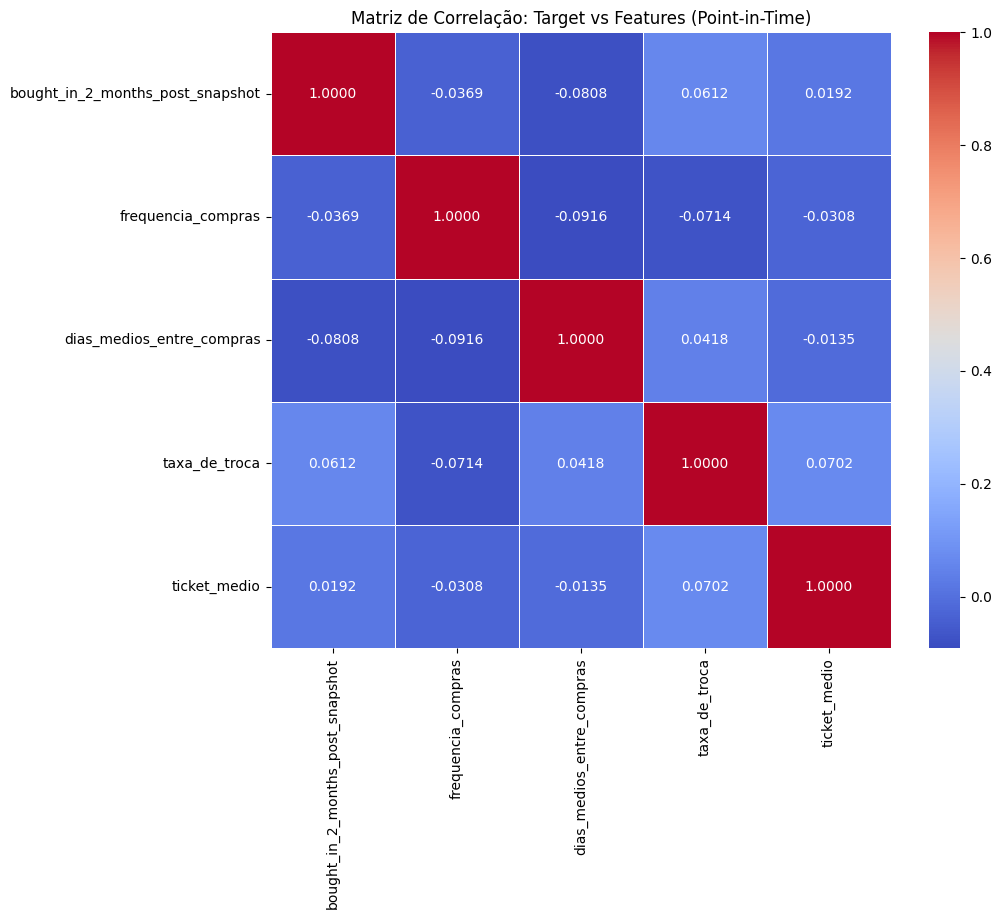


Correlação direta com o Target (ordenada):
bought_in_2_months_post_snapshot    1.000000
taxa_de_troca                       0.061195
ticket_medio                        0.019195
frequencia_compras                 -0.036940
dias_medios_entre_compras          -0.080758
Name: bought_in_2_months_post_snapshot, dtype: float64


In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

# Selecionando as colunas de interesse (numéricas e booleanas)
features_corr = [
    'bought_in_2_months_post_snapshot',
    'frequencia_compras',
    'dias_medios_entre_compras',
    'taxa_de_troca',
    'ticket_medio'
]

# Calculando a correlação
corr_matrix = customer_data_expanded[features_corr].corr()

# Configurando o plot
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.4f', linewidths=0.5)
plt.title('Matriz de Correlação: Target vs Features (Point-in-Time)')
plt.show()

# Exibindo a correlação específica com o target
print("\nCorrelação direta com o Target (ordenada):")
print(corr_matrix['bought_in_2_months_post_snapshot'].sort_values(ascending=False))

In [63]:
from sklearn.utils import resample

# 1. Verificar o desbalanceamento original
print("Distribuição original do Target:")
print(customer_data_expanded['bought_in_2_months_post_snapshot'].value_counts(normalize=True))

# 2. Separar as classes
df_majority = customer_data_expanded[customer_data_expanded['bought_in_2_months_post_snapshot'] == False]
df_minority = customer_data_expanded[customer_data_expanded['bought_in_2_months_post_snapshot'] == True]

# 3. Upsample da classe minoritária (True)
df_minority_upsampled = resample(df_minority,
                                 replace=True,     # Amostragem com reposição
                                 n_samples=len(df_majority),    # Igualar à classe majoritária
                                 random_state=42)  # Para reprodutibilidade

# 4. Combinar novamente os dados balanceados
customer_data_balanced = pd.concat([df_majority, df_minority_upsampled])

print("\nNova distribuição do Target após balanceamento (Oversampling):")
print(customer_data_balanced['bought_in_2_months_post_snapshot'].value_counts())

display(customer_data_balanced.head())

Distribuição original do Target:
bought_in_2_months_post_snapshot
False    0.978585
True     0.021415
Name: proportion, dtype: float64

Nova distribuição do Target após balanceamento (Oversampling):
bought_in_2_months_post_snapshot
False    36603
True     36603
Name: count, dtype: int64


,customer_id,snapshot_date,bought_in_2_months_post_snapshot,frequencia_compras,dias_medios_entre_compras,taxa_de_troca,ticket_medio
0,000bd487-a988-46ad-aecb-db390a11d47e,2025-12-01,False,5,997.5,0.2,182442.000000
1,00149129-072b-4579-9b98-f9a7858c6542,2025-12-01,False,2,1528.0,0.0,229609.835000
2,0014c0ee-431a-479e-af3f-7a649995448c,2025-12-01,False,2,642.0,0.0,159510.000000
3,0016e2dc-6a8f-4fcd-af1f-0d932cd05d68,2025-12-01,False,2,1447.0,0.0,341040.000000
4,00184324-d3be-42b2-8037-f7fb208042ba,2025-12-01,False,2,427.5,0.0,103493.333333


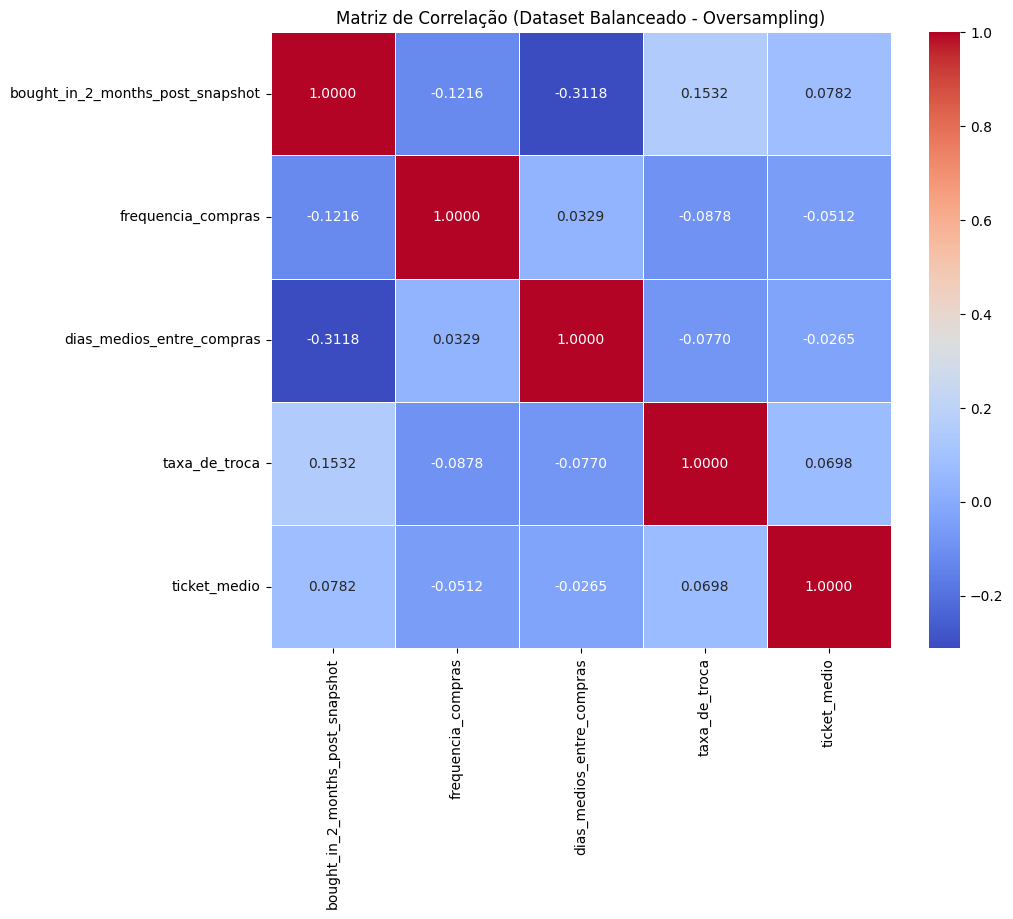


Correlação direta com o Target no Dataset Balanceado:
bought_in_2_months_post_snapshot    1.000000
taxa_de_troca                       0.153216
ticket_medio                        0.078155
frequencia_compras                 -0.121613
dias_medios_entre_compras          -0.311761
Name: bought_in_2_months_post_snapshot, dtype: float64


In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

# Selecionando as colunas numéricas e o target do dataset balanceado
features_corr = [
    'bought_in_2_months_post_snapshot',
    'frequencia_compras',
    'dias_medios_entre_compras',
    'taxa_de_troca',
    'ticket_medio'
]

# Calculando a correlação no dataframe balanceado
corr_matrix_balanced = customer_data_balanced[features_corr].corr()

# Configurando o plot
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix_balanced, annot=True, cmap='coolwarm', fmt='.4f', linewidths=0.5)
plt.title('Matriz de Correlação (Dataset Balanceado - Oversampling)')
plt.show()

# Exibindo a correlação direta com o Target
print("\nCorrelação direta com o Target no Dataset Balanceado:")
print(corr_matrix_balanced['bought_in_2_months_post_snapshot'].sort_values(ascending=False))

### Divisão de Treino e Teste

# Task
Prepare the data for clustering by selecting relevant numerical features from `customer_data`, scaling these features using `StandardScaler`, and storing the scaled data in a new DataFrame.

## Prepare Data for Clustering

### Subtask:
Select numerical features from `customer_data` that are suitable for clustering. Scale these features using `StandardScaler` to ensure all features contribute equally to the clustering process. Store the scaled data in a new DataFrame.


**Reasoning**:
To prepare the data for clustering, I will first select the numerical features from the `customer_data` DataFrame that are suitable for clustering as specified in the instructions. These features are 'frequencia_compras', 'dias_medios_entre_compras', 'taxa_de_troca', 'compras_mesmo_produto', and 'ticket_medio'.



In [ ]:
features_for_clustering = [
    'frequencia_compras',
    'dias_medios_entre_compras',
    'taxa_de_troca',
    'compras_mesmo_produto',
    'ticket_medio'
]

customer_features = customer_data[features_for_clustering].copy()
customer_features.head()

**Reasoning**:
Now that the relevant numerical features have been selected, I will instantiate a `StandardScaler`, apply it to the `customer_features` DataFrame using `fit_transform` to scale the data, and then create a new DataFrame, `customer_data_scaled`, retaining the original column names and index.



In [ ]:
scaler = StandardScaler()
customer_data_scaled_array = scaler.fit_transform(customer_features)
customer_data_scaled = pd.DataFrame(
    customer_data_scaled_array,
    columns=features_for_clustering,
    index=customer_features.index
)

# Display the head of the scaled DataFrame to verify
customer_data_scaled.head()

## Apply KMeans Clustering

### Subtask:
Apply the KMeans algorithm with `n_clusters=2` to the scaled customer data. Add the resulting cluster labels as a new column, 'cluster', to the original `customer_data` DataFrame.


**Reasoning**:
I will instantiate a KMeans model with `n_clusters=2`, `random_state=42`, and `n_init='auto'` to ensure reproducibility and suppress warnings. Then, I will fit this model to the `customer_data_scaled` DataFrame to perform the clustering.



In [ ]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init='auto')
kmeans.fit(customer_data_scaled)

print("KMeans model fitted successfully.")

**Reasoning**:
Now that the KMeans model has been fitted, I will add the generated cluster labels as a new 'cluster' column to the original `customer_data` DataFrame and display its head to verify the changes.



In [ ]:
customer_data['cluster'] = kmeans.labels_
customer_data.head()

## Analyze Cluster Characteristics

### Subtask:
Calculate the mean of each feature for each cluster to understand their distinct characteristics. Based on these characteristics, infer which cluster corresponds to 'pessoa física' and 'lojistas/frotistas' and assign these labels to the 'cluster_category' column in `customer_data`.


**Reasoning**:
To understand the distinct characteristics of each cluster, I will group the `customer_data` DataFrame by the 'cluster' column and calculate the mean for each of the clustering features. This will help in inferring which cluster corresponds to 'pessoa física' and 'lojistas/frotistas'.



In [ ]:
cluster_means = customer_data.groupby('cluster')[features_for_clustering].mean()
display(cluster_means)

**Reasoning**:
Based on the calculated mean values for each feature, I will infer which cluster (0 or 1) represents 'pessoa física' and 'lojistas/frotistas'. Cluster 0 shows lower exchange rates and average ticket values, with higher repeat purchases, which aligns with individual customers ('pessoa física'). Cluster 1 exhibits a very high exchange rate and higher average ticket values, which is characteristic of business customers ('lojistas/frotistas').



In [ ]:
cluster_mapping = {
    0: 'pessoa física',
    1: 'lojistas/frotistas'
}
customer_data['cluster_category'] = customer_data['cluster'].map(cluster_mapping)
customer_data.head()

## Visualize Customer Clusters

### Subtask:
Create a scatter plot of two significant features (e.g., 'frequencia_compras' and 'ticket_medio'), colored by the assigned 'cluster_category', to visualize the separation of the customer segments. Include appropriate labels and a legend.


**Reasoning**:
To visualize the customer segments, I will create a scatter plot using 'frequencia_compras' and 'ticket_medio' as axes, and 'cluster_category' for color-coding, as instructed.



In [ ]:
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=customer_data,
    x='frequencia_compras',
    y='ticket_medio',
    hue='cluster_category',
    palette='viridis',
    s=100, # size of points
    alpha=0.7 # transparency
)
plt.title('Customer Clusters: Frequência de Compras vs. Ticket Médio')
plt.xlabel('Frequência de Compras')
plt.ylabel('Ticket Médio')
plt.legend(title='Customer Category')
plt.grid(True)
plt.tight_layout()
plt.show()

## Final Task

### Subtask:
Present the identified customer segments, the assigned categories, and the visualization of the clusters. Summarize the key findings from the clustering analysis and discuss potential business implications.


## Summary:

### Q&A
*   **What are the identified customer segments and their assigned categories?**
    Two distinct customer segments were identified: 'pessoa física' (individual customers) and 'lojistas/frotistas' (shopkeepers/fleet owners).
*   **What are the key findings from the clustering analysis?**
    The clustering analysis revealed clear differences in purchasing behavior between the two segments, particularly in terms of purchase frequency, average days between purchases, exchange rates, repeat purchases of the same product, and average ticket value. These differences allowed for distinct categorization.
*   **How are the clusters visualized?**
    The customer clusters were visualized using a scatter plot comparing 'frequencia_compras' (purchase frequency) and 'ticket_medio' (average ticket value), with points colored according to their assigned 'cluster_category' (persona física or lojistas/frotistas), showing a clear separation between the groups.
*   **What are the potential business implications?**
    The segmentation provides a foundation for targeted marketing strategies, operational adjustments (e.g., optimizing return processes), and tailored product development for each customer group.

### Data Analysis Key Findings
*   **Data Preparation**: Five numerical features ('frequencia_compras', 'dias_medios_entre_compras', 'taxa_de_troca', 'compras_mesmo_produto', 'ticket_medio') were selected and successfully scaled using `StandardScaler`, preparing them for clustering.
*   **Customer Segmentation**: KMeans clustering with `n_clusters=2` successfully identified two distinct customer segments.
*   **Segment Characteristics**:
    *   **'Pessoa física' (Cluster 0)**: Exhibited higher purchase frequency ($\approx$1.44), significantly longer average days between purchases ($\approx$153.25 days), very low exchange rates ($\approx$0.0078), higher repeat purchases of the same product ($\approx$0.758), and a moderate average ticket value ($\approx$144,691).
    *   **'Lojistas/Frotistas' (Cluster 1)**: Showed lower purchase frequency ($\approx$1.10), much shorter average days between purchases ($\approx$42.66 days), extremely high exchange rates ($\approx$0.968), very low repeat purchases of the same product ($\approx$0.026), and a higher average ticket value ($\approx$210,348).
*   **Visual Separation**: The scatter plot visually confirmed the distinct separation between 'pessoa física' and 'lojistas/frotistas' based on 'frequencia_compras' and 'ticket_medio', validating the clustering results.

### Insights or Next Steps
*   Leverage these distinct customer segments to develop highly targeted marketing campaigns and product recommendations. For instance, 'Pessoa física' might benefit from loyalty programs and personalized offers based on past purchases, while 'Lojistas/Frotistas' could be targeted with bulk discounts, business solutions, or dedicated account management.
*   Investigate the reasons behind the extremely high exchange rates for 'Lojistas/Frotistas'. This could indicate opportunities for improving product descriptions, order accuracy, or return policies to enhance satisfaction and potentially reduce costs associated with returns.
